In [1]:
import tensorflow as tf
from tensorflow.keras import datasets
import matplotlib.pyplot as plt

# Load dataset
(X_train, y_train), (X_test, y_test) = datasets.mnist.load_data()

print("Training images:", X_train.shape)
print("Testing images:", X_test.shape)

2026-03-17 16:04:18.315526: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773763458.534281      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773763458.602399      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773763459.079925      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773763459.079974      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773763459.079978      55 computation_placer.cc:177] computation placer alr

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)


**Reduce Dataset Size**

In [2]:
X_train = X_train[:1000]
y_train = y_train[:1000]

X_test = X_test[:200]
y_test = y_test[:200]

**Preprocess the Data**

In [3]:
# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Add channel dimension
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

**Build CNN Model**

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-17 16:05:47.578168: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


**Compile Model**

In [5]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

**Train the Model**

In [7]:
model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9419 - loss: 0.1712 - val_accuracy: 0.9600 - val_loss: 0.1218
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9696 - loss: 0.1166 - val_accuracy: 0.9650 - val_loss: 0.1227
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9807 - loss: 0.0903 - val_accuracy: 0.9600 - val_loss: 0.1071
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9841 - loss: 0.0727 - val_accuracy: 0.9650 - val_loss: 0.1193
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9928 - loss: 0.0415 - val_accuracy: 0.9400 - val_loss: 0.1393


**Evaluate Model**

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

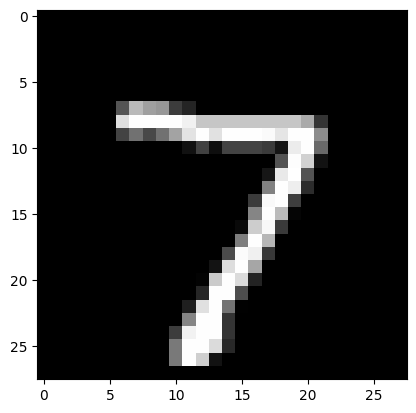

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Predicted digit: 7


In [9]:
import numpy as np

plt.imshow(X_test[0].reshape(28,28), cmap="gray")
plt.show()

prediction = np.argmax(model.predict(X_test[0].reshape(1,28,28,1)))
print("Predicted digit:", prediction)